In [1]:
import pandas as pd
df=pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [2]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [3]:
df=df.drop(columns=['dish_liked'])

In [4]:
#clean approx_cost column and convert to numeric format
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',','')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'],errors='coerce')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median())

In [5]:
#clean rate column and convert to numeric
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5','',regex=False)
df['rate'] = df['rate'].str.replace(' ','',regex=False)
df['rate'] = df['rate'].replace('NEW',None)
df['rate'] = df['rate'].replace('-',None)
df['rate'] = pd.to_numeric(df['rate'],errors = 'coerce')
df['rate'] = df['rate'].fillna(df['rate'].median())

In [6]:
df['phone'] = df['phone'].fillna('Not Available')
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['rest_type'] = df['rest_type'].fillna(df['rest_type'].mode()[0])
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median())
df['rate'] = df['rate'].fillna(df['rate'].median())

In [7]:
df.isnull().sum()

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [8]:
df['location'].value_counts().head(10)

location
BTM                      5145
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64

In [9]:
df[['name','rate']].sort_values(by='rate',ascending=False).head(10)

,name,rate
37843,Belgian Waffle Factory,4.9
34734,Asia Kitchen By Mainland China,4.9
10879,Asia Kitchen By Mainland China,4.9
39559,Punjab Grill,4.9
42381,Belgian Waffle Factory,4.9
29271,Asia Kitchen By Mainland China,4.9
32110,Asia Kitchen By Mainland China,4.9
49627,Byg Brewski Brewing Company,4.9
3921,Byg Brewski Brewing Company,4.9
4801,Byg Brewski Brewing Company,4.9


In [10]:
df.groupby('location')['rate'].mean()

location
BTM                  3.603557
Banashankari         3.658830
Banaswadi            3.552560
Bannerghatta Road    3.554110
Basavanagudi         3.674854
                       ...   
West Bangalore       3.533333
Whitefield           3.642164
Wilson Garden        3.575610
Yelahanka            3.650000
Yeshwantpur          3.514286
Name: rate, Length: 93, dtype: float64

In [11]:
df['online_order'].value_counts().head(10)


online_order
Yes    30444
No     21273
Name: count, dtype: int64

In [12]:
df[['name','approx_cost(for two people)']].sort_values(by = 'approx_cost(for two people)',ascending=False).head(10)

,name,approx_cost(for two people)
19139,Le Cirque Signature - The Leela Palace,6000.0
45618,Le Cirque Signature - The Leela Palace,6000.0
40266,Royal Afghan - ITC Windsor,5000.0
41591,Malties - Radisson Blu,4500.0
42141,Malties - Radisson Blu,4500.0
40262,La Brasserie - Le Meridien,4100.0
39416,La Brasserie - Le Meridien,4100.0
37715,La Brasserie - Le Meridien,4100.0
39125,La Brasserie - Le Meridien,4100.0
6104,Alba - JW Marriott Bengaluru,4000.0


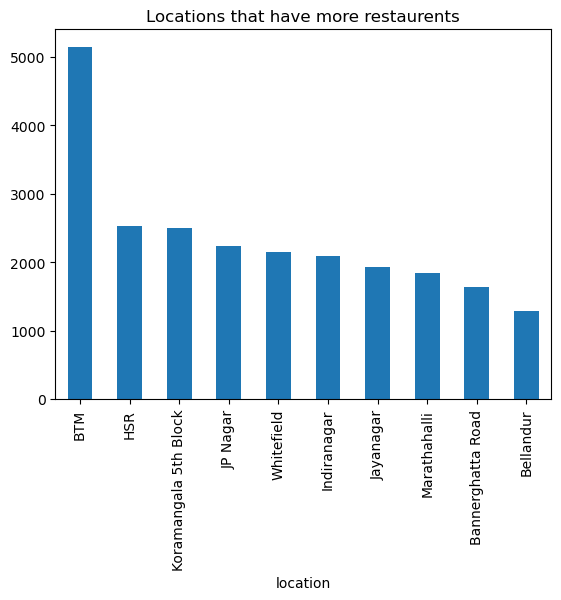

In [13]:
import matplotlib.pyplot as plt
df['location'].value_counts().head(10).plot(kind='bar')
plt.title('Locations that have more restaurents')
plt.show()

Text(0.5, 1.0, 'Top 10 Cuisines')

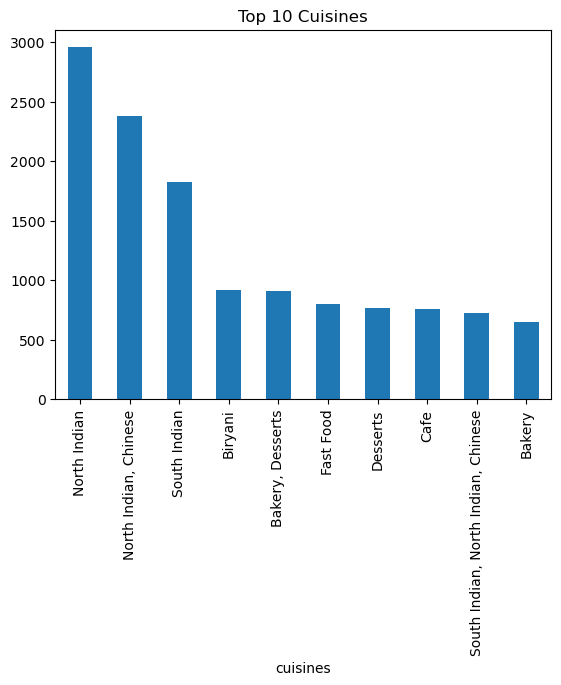

In [14]:
df['cuisines'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cuisines')

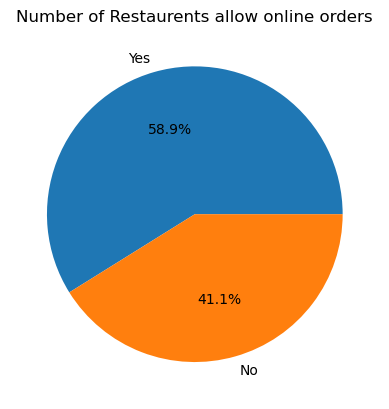

In [15]:
df['online_order'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Number of Restaurents allow online orders')
plt.ylabel('')
plt.show()

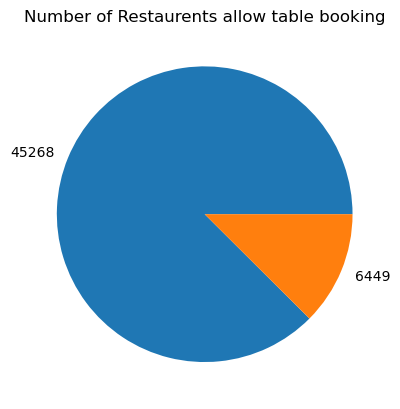

In [16]:
counts = df['book_table'].value_counts()
counts.plot(kind='pie',labels=counts)
plt.ylabel('')
plt.title('Number of Restaurents allow table booking')
plt.show()

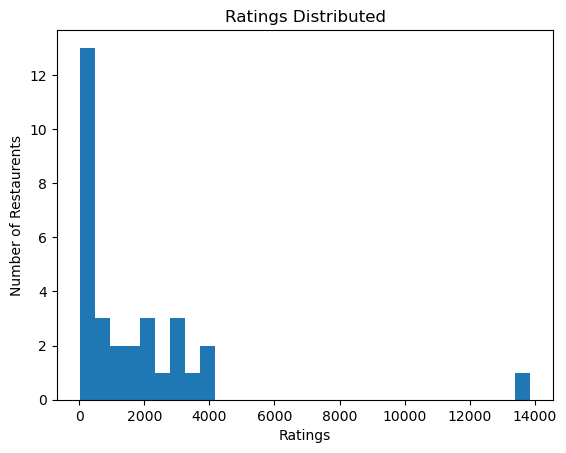

In [17]:
df['rate'].value_counts().plot(kind='hist',bins=30)#bins are used to get ranges
plt.title('Ratings Distributed')
plt.xlabel('Ratings')
plt.ylabel('Number of Restaurents')
plt.show()

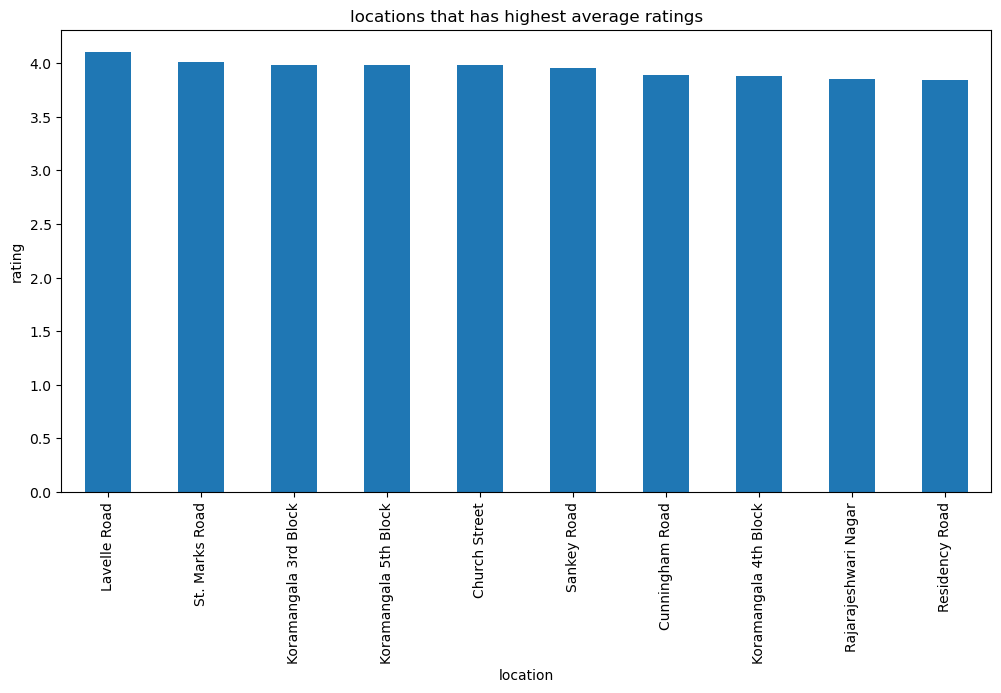

In [18]:
#locations that have highest rating
avg_rating=df.groupby('location')['rate'].mean().sort_values(ascending=False)
top_locations=avg_rating.head(10)
plt.figure(figsize=(12,6))#increase fig size orelse loation namee get overlaped
top_locations.plot(kind='bar')
plt.title("locations that has highest average ratings")
plt.xticks(rotation=90)#rotate location names
plt.xlabel('location')
plt.ylabel('rating')
plt.show()


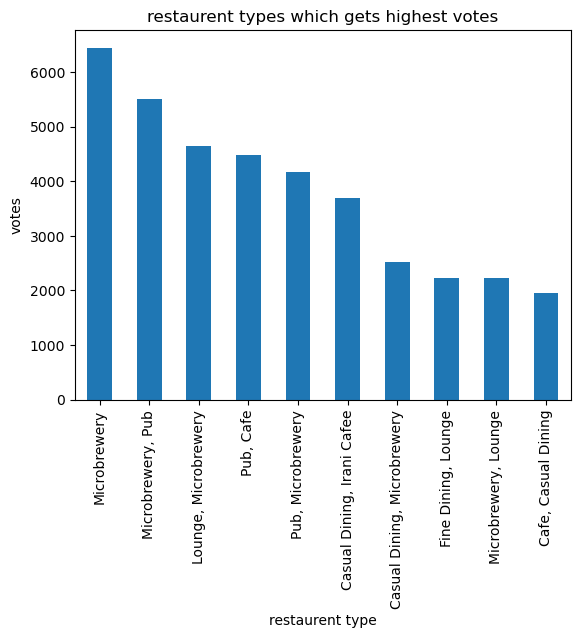

In [19]:
avg_votes=df.groupby('rest_type')['votes'].mean().sort_values(ascending=False)
top_votes = avg_votes.head(10)
top_votes.plot(kind='bar')
plt.title('restaurent types which gets highest votes')
plt.xlabel('restaurent type')
plt.ylabel('votes')
plt.show()

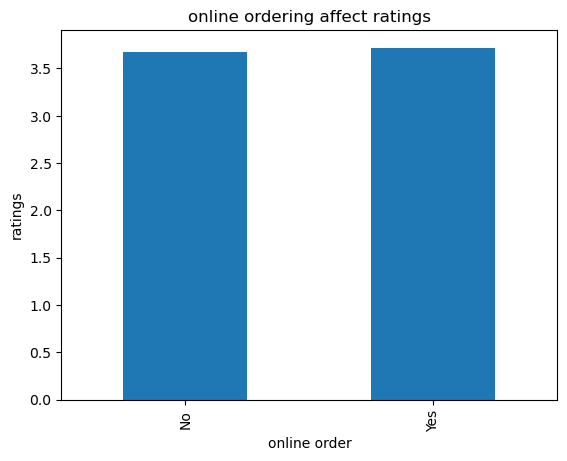

In [20]:
online_rating = df.groupby('online_order')['rate'].mean()
online_rating.plot(kind='bar')
plt.title('online ordering affect ratings')
plt.xlabel('online order')
plt.ylabel('ratings')
plt.show()

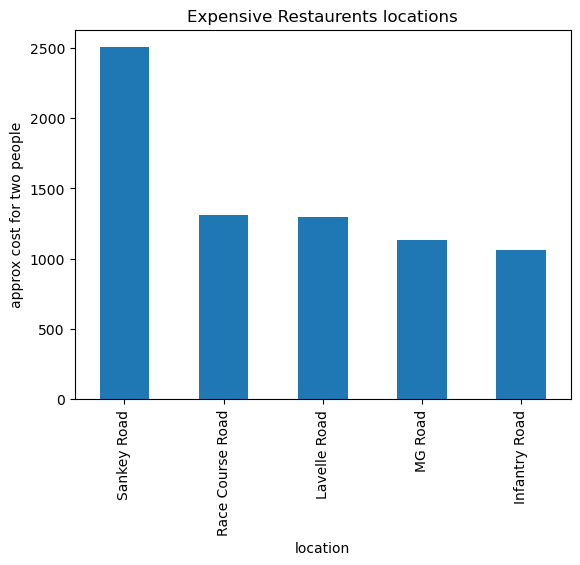

In [21]:
expensive_rest = df.groupby('location')['approx_cost(for two people)'].mean().sort_values(ascending=False)
expensive_rest = expensive_rest.head()
expensive_rest.plot(kind='bar')
plt.title('Expensive Restaurents locations')
plt.xlabel('location')
plt.ylabel('approx cost for two people')
plt.show()

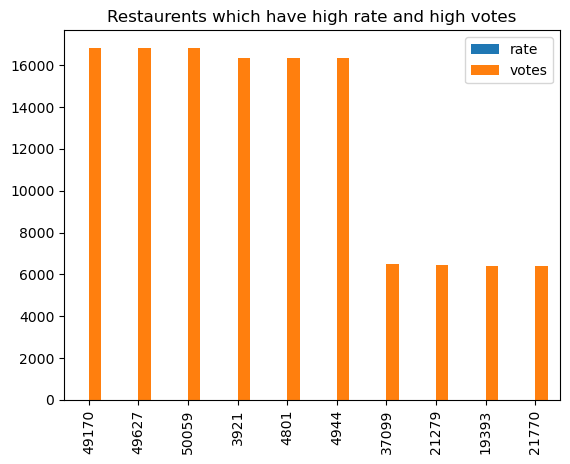

In [22]:
top_restaurants = df[['name','rate','votes']]
top_restaurants = top_restaurants.sort_values(by=['rate','votes'], ascending=False)
top_restaurants = top_restaurants.head(10)
top_restaurants.plot(kind='bar')
plt.title('Restaurents which have high rate and high votes')
plt.show()

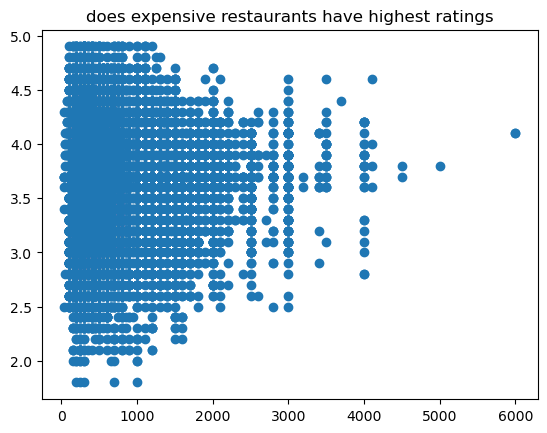

In [27]:

plt.scatter(df['approx_cost(for two people)'].sort_values(ascending=False),df['rate'])
plt.title('does expensive restaurants have highest ratings')
plt.show()

In [ ]:
df.to_csv("zomato_cleaned.csv",index=False)